In [1]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, OrdinalEncoder, MaxAbsScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score, recall_score, precision_score, make_scorer
from imblearn import FunctionSampler
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import make_column_selector as selector
import pandas as pd
from sklearn.model_selection import GroupKFold, StratifiedKFold, StratifiedGroupKFold, KFold, cross_validate, TimeSeriesSplit
from sklearn import set_config
from sklearn.base import clone
import warnings

# Esto hace que los steps de las pipelines sean df de pandas por defecto, sino serian np arrays
set_config(transform_output="pandas")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [2]:
df_claim_reviews = pd.read_csv("../data/claim_reviews.csv")

In [3]:
df_claim_reviews

,review_id,claim_id,review_round,review_datetime,reviewer_id,review_type,auto_risk_score,triage_result,reviewer_notes,perito_id,perito_physical_inspection,damage_consistency_rating,documentation_completeness_pct,recommended_action,days_since_claim
0,REV_00002_1,CLM_00002,1,2025-11-29 14:33:00,R-2512,Initial Triage,16.1,Green - Proceed,"Standard claim, within normal parameters.",NaN,NaN,NaN,NaN,Proceed,1
1,REV_00003_1,CLM_00003,1,2024-06-26 04:36:00,R-1744,Initial Triage,36.3,Yellow - Standard Review,Claimant was vague about accident circumstances.,NaN,NaN,NaN,NaN,Standard Review,2
2,REV_00003_2,CLM_00003,2,2024-07-29 21:36:00,R-1744,Expert Assessment,NaN,NaN,No anomalies found during review.,P-5992,No,2.2,60.2,Recommend Denial,35
3,REV_00003_3,CLM_00003,3,2024-08-15 13:36:00,SIU-209,SIU Investigation,NaN,NaN,Full investigation completed. Findings documen...,P-5992,Yes,NaN,NaN,Claim Denied,51
4,REV_00004_1,CLM_00004,1,2025-08-05 19:55:00,R-3644,Initial Triage,29.8,Green - Proceed,"All documents verified, consistent narrative.",NaN,NaN,NaN,NaN,Proceed,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20888,REV_15413_1,CLM_15413,1,2023-07-06 08:20:00,R-9461,Initial Triage,26.8,Green - Proceed,"Routine processing, no flags raised.",NaN,NaN,NaN,NaN,Proceed,1
20889,REV_15414_1,CLM_15414,1,2025-10-10 01:53:00,R-6221,Initial Triage,67.4,Orange - Escalated Review,Third party account differs slightly from clai...,NaN,NaN,NaN,NaN,Escalated Review,1
20890,REV_15414_2,CLM_15414,2,2025-10-16 13:53:00,R-6221,Expert Assessment,NaN,NaN,Documentation supports claim as reported.,P-8545,Yes,4.3,26.5,Approve with Conditions,7
20891,REV_15417_1,CLM_15417,1,2022-11-10 21:46:00,R-8044,Initial Triage,28.3,Green - Proceed,"Documentation complete, no issues detected.",NaN,NaN,NaN,NaN,Proceed,2


In [4]:
#Ver nulos

df_claim_reviews.isnull().sum()

review_id                             0
claim_id                              0
review_round                          0
review_datetime                       0
reviewer_id                           0
review_type                           0
auto_risk_score                    8626
triage_result                      8626
reviewer_notes                        0
perito_id                         12267
perito_physical_inspection        12267
damage_consistency_rating         13897
documentation_completeness_pct    13897
recommended_action                    0
days_since_claim                      0
dtype: int64

In [5]:
df_claim_reviews.describe(include='all')

,review_id,claim_id,review_round,review_datetime,reviewer_id,review_type,auto_risk_score,triage_result,reviewer_notes,perito_id,perito_physical_inspection,damage_consistency_rating,documentation_completeness_pct,recommended_action,days_since_claim
count,20893,20893,20893.000000,20893,20893,20893,12267.000000,12267,20893,8626,8626,6996.000000,6996.000000,20893,20893.000000
unique,20893,12267,NaN,20784,791,3,NaN,4,40,59,2,NaN,NaN,15,NaN
top,REV_15419_1,CLM_00008,NaN,2025-02-10 08:23:00,R-2207,Initial Triage,NaN,Green - Proceed,"Documentation complete, no issues detected.",P-9976,No,NaN,NaN,Proceed,NaN
freq,1,3,NaN,3,603,12267,NaN,6183,2391,309,4756,NaN,NaN,6183,NaN
mean,NaN,NaN,1.490882,NaN,NaN,NaN,30.992574,NaN,NaN,NaN,NaN,3.606718,80.303902,NaN,7.622218
std,NaN,NaN,0.637157,NaN,NaN,NaN,20.705931,NaN,NaN,NaN,NaN,0.892093,13.696789,NaN,9.188407
min,NaN,NaN,1.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,1.000000,14.700000,NaN,1.000000
25%,NaN,NaN,1.000000,NaN,NaN,NaN,15.200000,NaN,NaN,NaN,NaN,3.000000,71.575000,NaN,2.000000
50%,NaN,NaN,1.000000,NaN,NaN,NaN,29.700000,NaN,NaN,NaN,NaN,3.700000,81.050000,NaN,4.000000
75%,NaN,NaN,2.000000,NaN,NaN,NaN,45.400000,NaN,NaN,NaN,NaN,4.300000,90.700000,NaN,10.000000


CALCULO DEL TARGET

In [6]:
# Condición A: ronda 3 con resolución negativa SIU
cond_a_actions = {
    "Claim Denied",
    "Claim Withdrawn by Claimant",
    "Pending Litigation",
}
cond_a_claims = set(
    df_claim_reviews.loc[
        (df_claim_reviews["review_round"] == 3)
        & (df_claim_reviews["recommended_action"].isin(cond_a_actions)),
        "claim_id",
    ]
)

# Condición B: ronda 2 con acción desfavorable + inconsistencia de daños < 3.0
cond_b_actions = {
    "Recommend Denial",
    "Refer to Special Investigations Unit",
}
cond_b_claims = set(
    df_claim_reviews.loc[
        (df_claim_reviews["review_round"] == 2)
        & (df_claim_reviews["recommended_action"].isin(cond_b_actions))
        & (df_claim_reviews["damage_consistency_rating"] < 3.0),
        "claim_id",
    ]
)

# Condición C: ronda 1 roja + ronda 2 con inspección física y docs < 65
r1_red_claims = set(
    df_claim_reviews.loc[
        (df_claim_reviews["review_round"] == 1)
        & (df_claim_reviews["triage_result"] == "Red - Full Investigation"),
        "claim_id",
    ]
)
r2_severe_claims = set(
    df_claim_reviews.loc[
        (df_claim_reviews["review_round"] == 2)
        & (df_claim_reviews["perito_physical_inspection"] == "Yes")
        & (df_claim_reviews["documentation_completeness_pct"] < 65),
        "claim_id",
    ]
)
cond_c_claims = r1_red_claims & r2_severe_claims

# Unión lógica A OR B OR C
fraud_claims = cond_a_claims | cond_b_claims | cond_c_claims

# Target final por siniestro
df_target = (
    df_claim_reviews[["claim_id"]]
    .drop_duplicates()
    .assign(fraud_flag=lambda d: d["claim_id"].isin(fraud_claims).astype(int))
    .sort_values("claim_id")
    .reset_index(drop=True)
)

print("Nº siniestros:", len(df_target))
print("Fraudes (fraud_flag=1):", int(df_target["fraud_flag"].sum()))
print("No fraudes (fraud_flag=0):", int((df_target["fraud_flag"] == 0).sum()))

df_target.head(10)

Nº siniestros: 12267
Fraudes (fraud_flag=1): 878
No fraudes (fraud_flag=0): 11389


,claim_id,fraud_flag
0,CLM_00002,0
1,CLM_00003,1
2,CLM_00004,0
3,CLM_00005,0
4,CLM_00006,0
5,CLM_00007,0
6,CLM_00008,1
7,CLM_00009,0
8,CLM_00010,0
9,CLM_00012,0


In [7]:
df_target['fraud_flag'].value_counts(normalize=True)

fraud_flag
0    0.928426
1    0.071574
Name: proportion, dtype: float64

In [8]:
df_target

,claim_id,fraud_flag
0,CLM_00002,0
1,CLM_00003,1
2,CLM_00004,0
3,CLM_00005,0
4,CLM_00006,0
...,...,...
12262,CLM_15412,0
12263,CLM_15413,0
12264,CLM_15414,0
12265,CLM_15417,0


### Teniendo ya calculado el target, vamos a abandonar la tabla claim_reviews (en el readme.md se especifica que solo sirve para calcular el target)

In [9]:
df_claims = pd.read_csv("..\\data\\claims.csv")

In [10]:
df_claims

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop
0,CLM_00002,POL_07423,CUS_01111,VEH_01155,AGT_00118,2025-11-02 16:33:00,2025-11-28 06:33:00,Policy Holder,Urban,flooding damage,41.104921,-1.472463,Yes,Unknown,7,1198.91,Garage Ramírez - Murcia
1,CLM_00003,POL_01086,CUS_01750,VEH_00648,AGT_00027,2024-05-12 22:36:00,2024-06-23 15:36:00,Policy Holder,Urban,glass breakage,37.332902,-1.063439,No,Yes,7,11848.24,Carrocerías Díaz - Coruña
2,CLM_00004,POL_06373,CUS_06806,VEH_00899,AGT_00051,2025-07-09 22:55:00,2025-08-03 02:55:00,Policy Holder,Urban,bicycle involved,36.944930,-6.714446,Yes,No,2,1116.78,Carrocerías Díaz - Vigo
3,CLM_00005,POL_04543,CUS_04165,VEH_05968,AGT_00062,2023-11-08 20:14:00,2023-11-20 17:14:00,Policy Holder,Urban,multi-vehicle pileup,42.466545,2.320600,Yes,Yes,1,2246.88,Carrocerías Ruiz - Valencia
4,CLM_00006,POL_04676,CUS_07070,VEH_06082,AGT_00076,2025-08-21 12:39:00,2025-09-30 18:39:00,Policy Holder,Urban,falling object,39.341821,-2.414222,No,Yes,6,449.41,Carrocerías Gómez - Valencia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12262,CLM_15412,POL_07393,CUS_02209,VEH_07329,AGT_00123,2024-12-17 11:01:00,2024-12-26 16:01:00,Policy Holder,Suburban,pedestrian involved,39.549568,0.227634,Yes,No,0,960.23,Mecánica Rubio - Málaga
12263,CLM_15413,POL_00752,CUS_05111,VEH_02884,AGT_00105,2023-06-24 02:20:00,2023-07-04 19:20:00,Policy Holder,Urban,theft attempt,38.652884,-3.561560,No,No,2,1843.21,Taller Domínguez - Alicante
12264,CLM_15414,POL_04232,CUS_01224,VEH_03091,AGT_00042,2025-09-10 06:53:00,2025-10-08 17:53:00,Policy Holder,Urban,theft attempt,38.648536,-6.392743,No,Yes,2,957.81,Taller Rivera - Alicante
12265,CLM_15417,POL_02434,CUS_01106,VEH_06088,AGT_00173,2022-10-11 14:46:00,2022-11-08 04:46:00,Policy Holder,Urban,weather-related,42.800512,-3.779887,No,No,5,2349.20,Chapa y Pintura Castillo - Las Palmas


In [11]:
df_claims.isnull().sum()

claim_id                 0
policy_id                0
customer_id              0
vehicle_id               0
agent_id                 0
accident_datetime        0
claim_datetime           0
fault                    0
accident_area            0
accident_description     0
accident_latitude        0
accident_longitude       0
police_report_filed      0
witness_present          0
number_of_supplements    0
claimed_amount_eur       0
repair_workshop          0
dtype: int64

In [12]:
df_claims.describe(include='all')

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop
count,12267,12267,12267,12267,12267,12267,12267,12267,12267,12267,12267.000000,12267.000000,12267,12267,12267.000000,12267.000000,12267
unique,12267,6167,3759,6594,180,12227,12228,2,5,20,NaN,NaN,3,3,NaN,NaN,387
top,CLM_15419,POL_00734,CUS_00250,VEH_08192,AGT_00016,2025-05-31 09:23:00,2024-01-11 16:56:00,Policy Holder,Urban,fire damage,NaN,NaN,No,No,NaN,NaN,Carrocerías Ramírez - Vitoria
freq,1,7,19,7,96,2,2,8017,4879,654,NaN,NaN,6684,7194,NaN,NaN,80
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.850914,-2.970615,NaN,NaN,3.477541,2999.131380,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.252370,3.624874,NaN,NaN,2.279481,3873.780393,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.000737,-9.299434,NaN,NaN,0.000000,47.330000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.889615,-6.085252,NaN,NaN,1.000000,912.225000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.833320,-2.989663,NaN,NaN,3.000000,1822.520000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.788675,0.189406,NaN,NaN,5.000000,3555.105000,NaN


In [13]:
df_customers = pd.read_csv("..\\data\\customers.csv")

In [14]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5760 entries, 0 to 5759
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               5760 non-null   object
 1   full_name                 5760 non-null   object
 2   sex                       5760 non-null   object
 3   marital_status            5760 non-null   object
 4   date_of_birth             5760 non-null   object
 5   email                     5760 non-null   object
 6   phone                     5760 non-null   object
 7   address                   5760 non-null   object
 8   city                      5760 non-null   object
 9   province                  5760 non-null   object
 10  postal_code               5760 non-null   int64 
 11  last_address_change_date  3099 non-null   object
dtypes: int64(1), object(11)
memory usage: 540.1+ KB


In [15]:
# Miro nulos por qué en la última columna parece que hay
df_customers.isnull().sum()

customer_id                    0
full_name                      0
sex                            0
marital_status                 0
date_of_birth                  0
email                          0
phone                          0
address                        0
city                           0
province                       0
postal_code                    0
last_address_change_date    2661
dtype: int64

In [16]:
df_customers.describe(include='all')

,customer_id,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date
count,5760,5760,5760,5760,5760,5760,5760,5760,5760,5760,5760.000000,3099
unique,5760,5502,2,4,5089,5760,5759,5572,40,29,NaN,1271
top,CUS_07179,Manuel Morales Jiménez,Male,Married,1983-11-26,andres.vazquez628@telefonica.net,+34 616 755 616,105 Cypress Blvd,Córdoba,Madrid,NaN,2025-03-31
freq,1,3,3142,2524,4,1,2,4,164,863,NaN,11
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27175.066493,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14944.518719,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1002.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14241.500000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27420.500000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40186.000000,NaN


# Columna last_address_change_date
Los nulos que hay en last_address_change_date son por que no se han cambiado de dirección, por lo que lo cambio por No Change
Hacer una columna sustituyendo a last_address_change_date que sea Si o No han cambiado
Borrarla
# Columnas de address, city, province y postal_code
Decidir cuáles borrar o cuál quedarse, por qué por ejemplo postal code no tiene mucho sentido teniendo la ciudad.
Yo me quedaría con city y province que son las que menor cardinalidad tienen

# Más features
policy_age_days = days(claim_date - policy_start_date). Razon: riesgo mayor en pólizas muy nuevas

submission_delay_days = days(claim_datetime - accident_datetime). Razon: retrasos anómalos indican fraude.

policyholder_vs_claimant_same (bool: policies.customer_id == claims.customer_id). Razon: reclamaciones por terceros vs titular.

accident_in_same_province_as_customer (bool) usando accident_lat/long o city/province. Razon: reclamos fuera de zona pueden ser sospechosos.



In [17]:
df_policies = pd.read_csv("..\\data\\policies.csv")
df_vehicles = pd.read_csv("..\\data\\vehicles.csv")

In [18]:
df_policies

,policy_id,customer_id,policy_type,base_policy,deductible,annual_premium_eur,policy_start_date,policy_end_date,past_number_of_claims,number_of_cars
0,POL_00001,CUS_03475,Sport - Collision,Collision,300,1584.19,2022-04-22,2023-04-22,none,7
1,POL_00002,CUS_02564,Sport - Liability,Liability,500,499.00,2021-01-05,2022-01-05,more than 4,1
2,POL_00003,CUS_03003,Utility - Liability,Liability,700,1678.45,2024-04-06,2025-04-06,none,3
3,POL_00004,CUS_02879,Sedan - Collision,Collision,300,1161.30,2018-10-03,2019-10-03,1,1
4,POL_00005,CUS_00266,Utility - All Perils,All Perils,700,525.80,2020-10-31,2021-10-31,more than 4,1
...,...,...,...,...,...,...,...,...,...,...
7611,POL_09493,CUS_05458,Sport - All Perils,All Perils,500,1023.03,2024-05-17,2025-05-17,2,2
7612,POL_09496,CUS_03334,Sport - Collision,Collision,700,911.71,2024-03-23,2025-03-23,1,1
7613,POL_09497,CUS_00802,Sedan - Liability,Liability,700,835.37,2022-08-15,2023-08-15,none,1
7614,POL_09498,CUS_04069,Sedan - Collision,Collision,300,3157.89,2021-03-29,2022-03-29,4,2


In [19]:
df_policies.describe(include='all')

,policy_id,customer_id,policy_type,base_policy,deductible,annual_premium_eur,policy_start_date,policy_end_date,past_number_of_claims,number_of_cars
count,7616,7616,7616,7616,7616.000000,7616.000000,7616,7616,7616,7616.000000
unique,7616,4213,9,3,NaN,NaN,2373,2373,6,NaN
top,POL_09477,CUS_03024,Sport - Liability,Liability,NaN,NaN,2020-10-31,2021-10-31,none,NaN
freq,1,8,888,2596,NaN,NaN,10,10,2244,NaN
mean,NaN,NaN,NaN,NaN,452.166492,752.425376,NaN,NaN,NaN,4.477810
std,NaN,NaN,NaN,NaN,129.995329,400.533312,NaN,NaN,NaN,2.275169
min,NaN,NaN,NaN,NaN,300.000000,85.300000,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,400.000000,475.567500,NaN,NaN,NaN,3.000000
50%,NaN,NaN,NaN,NaN,400.000000,666.870000,NaN,NaN,NaN,4.000000
75%,NaN,NaN,NaN,NaN,500.000000,927.937500,NaN,NaN,NaN,6.000000


In [20]:
df_vehicles

,vehicle_id,policy_id,license_plate,make,model,manufacture_year,vehicle_category,purchase_price_eur,color,odometer_km,driver_rating
0,VEH_00000,POL_05817,3486 XMR,Toyota,Hilux,2024,Utility,17476.28,Negro,203751,1
1,VEH_00001,POL_06074,9916 KVH,Volvo,XC60,2013,Utility,17966.90,Blanco,118504,3
2,VEH_00002,POL_09056,2787 NWJ,Jaguar,F-Pace,2024,Coupe,10593.51,Blanco,220197,2
3,VEH_00003,POL_06022,6635 CLH,SEAT,Arona,2013,Sedan,36615.40,Blanco,92432,4
4,VEH_00005,POL_06071,6905 HFG,Kia,Rio,2005,SUV,18241.39,Gris,206190,1
...,...,...,...,...,...,...,...,...,...,...,...
6999,VEH_08793,POL_03097,8977 XTB,Nissan,Leaf,2021,Sedan,70410.92,Plata,241831,2
7000,VEH_08794,POL_01633,4119 NJY,Citroën,C5 Aircross,2009,SUV,12993.44,Plata,247804,2
7001,VEH_08795,POL_07575,9016 JMB,Citroën,C4,2015,SUV,8973.63,Negro,21684,3
7002,VEH_08798,POL_04575,0864 YNM,Citroën,C5 Aircross,2018,Sedan,12148.37,Gris,89800,2


In [21]:
df_vehicles.describe(include='all')

,vehicle_id,policy_id,license_plate,make,model,manufacture_year,vehicle_category,purchase_price_eur,color,odometer_km,driver_rating
count,7004,7004,7004,7004,7004,7004.000000,7004,7004.000000,7004,7004.000000,7004.000000
unique,7004,4604,7004,30,172,NaN,6,NaN,11,NaN,NaN
top,VEH_08799,POL_00540,3781 CJH,Volkswagen,Berlingo,NaN,Sedan,NaN,Blanco,NaN,NaN
freq,1,6,1,258,65,NaN,2457,NaN,1370,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,2014.564963,NaN,21688.400938,NaN,140282.830240,2.172616
std,NaN,NaN,NaN,NaN,NaN,5.821509,NaN,14283.256374,NaN,80398.564593,0.965809
min,NaN,NaN,NaN,NaN,NaN,2005.000000,NaN,2094.690000,NaN,506.000000,1.000000
25%,NaN,NaN,NaN,NaN,NaN,2009.000000,NaN,11988.257500,NaN,70006.500000,1.000000
50%,NaN,NaN,NaN,NaN,NaN,2015.000000,NaN,17963.130000,NaN,138858.000000,2.000000
75%,NaN,NaN,NaN,NaN,NaN,2020.000000,NaN,27143.297500,NaN,210253.000000,3.000000


# PIPELINE BÁSICA

### HACER LOS MERGERS

In [22]:
# Partir de claims (cada fila = 1 siniestro)

# 1. Cruzamos con policies solo por policy_id (eliminamos customer_id para evitar duplicado)
df = df_claims.merge(
    df_policies.drop(columns=['customer_id']), 
    on="policy_id", 
    how="left"
)

# 2. Cruzamos con customers por customer_id
df = df.merge(df_customers, on="customer_id", how="left")

# 3. Cruzamos con vehicles por vehicle_id (eliminamos policy_id para evitar duplicado)
df = df.merge(
    df_vehicles.drop(columns=['policy_id']), 
    on="vehicle_id",  
    how="left"
)

print(df.shape)

(12267, 45)


In [23]:
df

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop,policy_type,base_policy,deductible,annual_premium_eur,policy_start_date,policy_end_date,past_number_of_claims,number_of_cars,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date,license_plate,make,model,manufacture_year,vehicle_category,purchase_price_eur,color,odometer_km,driver_rating
0,CLM_00002,POL_07423,CUS_01111,VEH_01155,AGT_00118,2025-11-02 16:33:00,2025-11-28 06:33:00,Policy Holder,Urban,flooding damage,41.104921,-1.472463,Yes,Unknown,7,1198.91,Garage Ramírez - Murcia,Sedan - All Perils,All Perils,300,659.45,2024-05-09,2025-05-09,none,6,Teresa Flores Blanco,Female,Married,1941-07-22,teresa.flores323@hotmail.com,+34 619 772 219,154 Olive Rd,Albacete,Albacete,7046,NaN,1844 XYN,Lexus,NX,2019.0,Coupe,32542.84,Negro,54998.0,3.0
1,CLM_00003,POL_01086,CUS_01750,VEH_00648,AGT_00027,2024-05-12 22:36:00,2024-06-23 15:36:00,Policy Holder,Urban,glass breakage,37.332902,-1.063439,No,Yes,7,11848.24,Carrocerías Díaz - Coruña,Sport - All Perils,All Perils,300,293.08,2021-11-11,2022-11-11,1,3,Paula González Gómez,Female,Married,2004-10-04,paula.gonzalez914@gmail.com,+34 698 603 915,451 Oak St,Fuenlabrada,Madrid,13010,2025-01-07,2010 LCJ,Suzuki,Swift,2007.0,Sedan,57394.78,Blanco,68453.0,2.0
2,CLM_00004,POL_06373,CUS_06806,VEH_00899,AGT_00051,2025-07-09 22:55:00,2025-08-03 02:55:00,Policy Holder,Urban,bicycle involved,36.944930,-6.714446,Yes,No,2,1116.78,Carrocerías Díaz - Vigo,Sport - Collision,Collision,500,1098.78,2024-06-24,2025-06-24,1,2,Miguel Hernández Díaz,Male,Married,1943-12-11,miguel.hernandez440@yahoo.es,+34 655 140 464,194 Spruce Dr,Granada,Granada,7790,NaN,5217 ZCT,Opel,Corsa,2015.0,Coupe,11722.73,Negro,43399.0,1.0
3,CLM_00005,POL_04543,CUS_04165,VEH_05968,AGT_00062,2023-11-08 20:14:00,2023-11-20 17:14:00,Policy Holder,Urban,multi-vehicle pileup,42.466545,2.320600,Yes,Yes,1,2246.88,Carrocerías Ruiz - Valencia,Utility - All Perils,All Perils,400,779.88,2022-11-08,2023-11-08,3,1,Francisco Romero Núñez,Male,Widow,1983-09-02,francisco.romero761@mail.com,+34 619 475 863,345 Willow Way,Logroño,La Rioja,26498,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CLM_00006,POL_04676,CUS_07070,VEH_06082,AGT_00076,2025-08-21 12:39:00,2025-09-30 18:39:00,Policy Holder,Urban,falling object,39.341821,-2.414222,No,Yes,6,449.41,Carrocerías Gómez - Valencia,Utility - All Perils,All Perils,300,529.95,2023-07-02,2024-07-01,1,6,Silvia Vázquez Rodríguez,Female,Divorced,1977-11-14,silvia.vazquez100@mail.com,+34 617 803 407,335 Oak Way,Coruña,A Coruña,25056,NaN,8590 FGD,Chevrolet,Malibu,2013.0,Coupe,15236.23,Negro,86004.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12262,CLM_15412,POL_07393,CUS_02209,VEH_07329,AGT_00123,2024-12-17 11:01:00,2024-12-26 16:01:00,Policy Holder,Suburban,pedestrian involved,39.549568,0.227634,Yes,No,0,960.23,Mecánica Rubio - Málaga,Sport - All Perils,All Perils,500,800.01,2022-09-17,2023-09-17,none,4,Ana Ramos Reyes,Female,Married,1955-12-02,ana.ramos856@yahoo.es,+34 697 384 886,244 Pine Ln,Barcelona,Barcelona,52526,2024-09-10,6942 KZS,Honda,Fit,2006.0,Sedan,25053.98,Plata,147988.0,4.0
12263,CLM_15413,POL_00752,CUS_05111,VEH_02884,AGT_00105,2023-06-24 02:20:00,2023-07-04 19:20:00,Policy Holder,Urban,theft attempt,38.652884,-3.561560,No,No,2,1843.21,Taller Domínguez - Alicante,Sedan - Collision,Collision,300,534.85,2020-02-24,2021-02-23,3,3,Raúl Gil Jiménez,Male,Single,2005-07-13,raul.gil207@gmail.com,+34 661 953 759,361 Maple Dr,Bilbao,Vizcaya,27669,2024-10-19,9627 RXP,Ford,Focus,2021.0,Sedan,36572.27,Blanco,256229.0,4.0
12264,CLM_15414,POL_04232,CUS_01224,VEH_03091,AGT_00042,

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12267 entries, 0 to 12266
Data columns (total 45 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   claim_id                  12267 non-null  object 
 1   policy_id                 12267 non-null  object 
 2   customer_id               12267 non-null  object 
 3   vehicle_id                12267 non-null  object 
 4   agent_id                  12267 non-null  object 
 5   accident_datetime         12267 non-null  object 
 6   claim_datetime            12267 non-null  object 
 7   fault                     12267 non-null  object 
 8   accident_area             12267 non-null  object 
 9   accident_description      12267 non-null  object 
 10  accident_latitude         12267 non-null  float64
 11  accident_longitude        12267 non-null  float64
 12  police_report_filed       12267 non-null  object 
 13  witness_present           12267 non-null  object 
 14  number

In [25]:
df_target = pd.read_csv("..\\data\\df_target.csv")

# Añadir fraud_flag al dataframe principal por claim_id
df = df.merge(df_target, on="claim_id", how="left")

print(df.shape)          # → (12267, 46)
print(df['fraud_flag'].value_counts())
print(f"Tasa de fraude: {df['fraud_flag'].mean():.2%}")

(12267, 46)
fraud_flag
0    11389
1      878
Name: count, dtype: int64
Tasa de fraude: 7.16%


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12267 entries, 0 to 12266
Data columns (total 46 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   claim_id                  12267 non-null  object 
 1   policy_id                 12267 non-null  object 
 2   customer_id               12267 non-null  object 
 3   vehicle_id                12267 non-null  object 
 4   agent_id                  12267 non-null  object 
 5   accident_datetime         12267 non-null  object 
 6   claim_datetime            12267 non-null  object 
 7   fault                     12267 non-null  object 
 8   accident_area             12267 non-null  object 
 9   accident_description      12267 non-null  object 
 10  accident_latitude         12267 non-null  float64
 11  accident_longitude        12267 non-null  float64
 12  police_report_filed       12267 non-null  object 
 13  witness_present           12267 non-null  object 
 14  number

In [27]:
df.describe(include='all')

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop,policy_type,base_policy,deductible,annual_premium_eur,policy_start_date,policy_end_date,past_number_of_claims,number_of_cars,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date,license_plate,make,model,manufacture_year,vehicle_category,purchase_price_eur,color,odometer_km,driver_rating,fraud_flag
count,12267,12267,12267,12267,12267,12267,12267,12267,12267,12267,12267.000000,12267.000000,12267,12267,12267.000000,12267.000000,12267,12267,12267,12267.000000,12267.000000,12267,12267,12267,12267.000000,12267,12267,12267,12267,12267,12267,12267,12267,12267,12267.000000,6685,9758,9758,9758,9758.000000,9758,9758.000000,9758,9758.000000,9758.000000,12267.000000
unique,12267,6167,3759,6594,180,12227,12228,2,5,20,NaN,NaN,3,3,NaN,NaN,387,9,3,NaN,NaN,2264,2264,6,NaN,3643,2,4,3453,3759,3758,3678,40,29,NaN,1030,5247,30,172,NaN,6,NaN,11,NaN,NaN,NaN
top,CLM_15419,POL_00734,CUS_00250,VEH_08192,AGT_00016,2025-05-31 09:23:00,2024-01-11 16:56:00,Policy Holder,Urban,fire damage,NaN,NaN,No,No,NaN,NaN,Carrocerías Ramírez - Vitoria,Sport - All Perils,Liability,NaN,NaN,2024-05-05,2025-05-05,none,NaN,Cristina Ruiz Ortega,Male,Married,1954-11-04,cristina.ruiz217@telefonica.net,+34 620 153 186,17 Laurel Blvd,Vitoria,Madrid,NaN,2025-03-08,1234 BZY,Suzuki,Malibu,NaN,Sedan,NaN,Blanco,NaN,NaN,NaN
freq,1,7,19,7,96,2,2,8017,4879,654,NaN,NaN,6684,7194,NaN,NaN,80,1462,4143,NaN,NaN,19,19,3642,NaN,20,6607,5264,19,19,19,19,396,1850,NaN,30,7,395,91,NaN,3411,NaN,1895,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.850914,-2.970615,NaN,NaN,3.477541,2999.131380,NaN,NaN,NaN,451.389908,752.307359,NaN,NaN,NaN,4.502975,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27578.675634,NaN,NaN,NaN,NaN,2014.633122,NaN,21771.210658,NaN,139430.233757,2.178315,0.071574
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.252370,3.624874,NaN,NaN,2.279481,3873.780393,NaN,NaN,NaN,129.657264,400.039304,NaN,NaN,NaN,2.283271,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14850.843899,NaN,NaN,NaN,NaN,5.798472,NaN,14359.113876,NaN,79664.252818,0.966898,0.257792
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.000737,-9.299434,NaN,NaN,0.000000,47.330000,NaN,NaN,NaN,300.000000,85.300000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1002.000000,NaN,NaN,NaN,NaN,2005.000000,NaN,2094.690000,NaN,506.000000,1.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.889615,-6.085252,NaN,NaN,1.000000,912.225000,NaN,NaN,NaN,400.000000,474.765000,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14857.000000,NaN,NaN,NaN,NaN,2010.000000,NaN,12001.700000,NaN,69809.000000,1.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.833320,-2.989663,NaN,NaN,3.000000,1822.520000,NaN,NaN,NaN,400.000000,671.370000,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28187.000000,NaN,NaN,NaN,NaN,2015.000000,NaN,18010.585000,NaN,138015.000000,2.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.788675,0.189406,NaN,NaN,5.000000,3555.105000,NaN,NaN,NaN,500.000000,923.785000,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40514.000000,NaN,NaN,NaN,NaN,2020.000000,NaN,27070.080000,NaN,208078.500000,3.000000,0.000000


In [28]:
df

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop,policy_type,base_policy,deductible,annual_premium_eur,policy_start_date,policy_end_date,past_number_of_claims,number_of_cars,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date,license_plate,make,model,manufacture_year,vehicle_category,purchase_price_eur,color,odometer_km,driver_rating,fraud_flag
0,CLM_00002,POL_07423,CUS_01111,VEH_01155,AGT_00118,2025-11-02 16:33:00,2025-11-28 06:33:00,Policy Holder,Urban,flooding damage,41.104921,-1.472463,Yes,Unknown,7,1198.91,Garage Ramírez - Murcia,Sedan - All Perils,All Perils,300,659.45,2024-05-09,2025-05-09,none,6,Teresa Flores Blanco,Female,Married,1941-07-22,teresa.flores323@hotmail.com,+34 619 772 219,154 Olive Rd,Albacete,Albacete,7046,NaN,1844 XYN,Lexus,NX,2019.0,Coupe,32542.84,Negro,54998.0,3.0,0
1,CLM_00003,POL_01086,CUS_01750,VEH_00648,AGT_00027,2024-05-12 22:36:00,2024-06-23 15:36:00,Policy Holder,Urban,glass breakage,37.332902,-1.063439,No,Yes,7,11848.24,Carrocerías Díaz - Coruña,Sport - All Perils,All Perils,300,293.08,2021-11-11,2022-11-11,1,3,Paula González Gómez,Female,Married,2004-10-04,paula.gonzalez914@gmail.com,+34 698 603 915,451 Oak St,Fuenlabrada,Madrid,13010,2025-01-07,2010 LCJ,Suzuki,Swift,2007.0,Sedan,57394.78,Blanco,68453.0,2.0,1
2,CLM_00004,POL_06373,CUS_06806,VEH_00899,AGT_00051,2025-07-09 22:55:00,2025-08-03 02:55:00,Policy Holder,Urban,bicycle involved,36.944930,-6.714446,Yes,No,2,1116.78,Carrocerías Díaz - Vigo,Sport - Collision,Collision,500,1098.78,2024-06-24,2025-06-24,1,2,Miguel Hernández Díaz,Male,Married,1943-12-11,miguel.hernandez440@yahoo.es,+34 655 140 464,194 Spruce Dr,Granada,Granada,7790,NaN,5217 ZCT,Opel,Corsa,2015.0,Coupe,11722.73,Negro,43399.0,1.0,0
3,CLM_00005,POL_04543,CUS_04165,VEH_05968,AGT_00062,2023-11-08 20:14:00,2023-11-20 17:14:00,Policy Holder,Urban,multi-vehicle pileup,42.466545,2.320600,Yes,Yes,1,2246.88,Carrocerías Ruiz - Valencia,Utility - All Perils,All Perils,400,779.88,2022-11-08,2023-11-08,3,1,Francisco Romero Núñez,Male,Widow,1983-09-02,francisco.romero761@mail.com,+34 619 475 863,345 Willow Way,Logroño,La Rioja,26498,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,CLM_00006,POL_04676,CUS_07070,VEH_06082,AGT_00076,2025-08-21 12:39:00,2025-09-30 18:39:00,Policy Holder,Urban,falling object,39.341821,-2.414222,No,Yes,6,449.41,Carrocerías Gómez - Valencia,Utility - All Perils,All Perils,300,529.95,2023-07-02,2024-07-01,1,6,Silvia Vázquez Rodríguez,Female,Divorced,1977-11-14,silvia.vazquez100@mail.com,+34 617 803 407,335 Oak Way,Coruña,A Coruña,25056,NaN,8590 FGD,Chevrolet,Malibu,2013.0,Coupe,15236.23,Negro,86004.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12262,CLM_15412,POL_07393,CUS_02209,VEH_07329,AGT_00123,2024-12-17 11:01:00,2024-12-26 16:01:00,Policy Holder,Suburban,pedestrian involved,39.549568,0.227634,Yes,No,0,960.23,Mecánica Rubio - Málaga,Sport - All Perils,All Perils,500,800.01,2022-09-17,2023-09-17,none,4,Ana Ramos Reyes,Female,Married,1955-12-02,ana.ramos856@yahoo.es,+34 697 384 886,244 Pine Ln,Barcelona,Barcelona,52526,2024-09-10,6942 KZS,Honda,Fit,2006.0,Sedan,25053.98,Plata,147988.0,4.0,0
12263,CLM_15413,POL_00752,CUS_05111,VEH_02884,AGT_00105,2023-06-24 02:20:00,2023-07-04 19:20:00,Policy Holder,Urban,theft attempt,38.652884,-3.561560,No,No,2,1843.21,Taller Domínguez - Alicante,Sedan - Collision,Collision,300,534.85,2020-02-24,2021-02-23,3,3,Raúl Gil Jiménez,Male,Single,2005-07-13,raul.gil207@gmail.com,+34 661 953 759,361 Maple Dr,Bilbao,Vizcaya,27669,2024-10-19,9627 RXP,Ford,Focus,2021.0,Sedan,36572.27,Blanco,256229.0,4.0,0
12264,CLM_15414,POL_04232,C

# CONSTRUCCION DE LA PIPELINE BASICA

In [29]:
def get_train_test_split(train_df):

  # Train-test split (recordar cambiar la target)
  X = train_df.drop(columns="fraud_flag")
  y = train_df["fraud_flag"]
  X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

  return X_train, X_val, y_train, y_val

In [30]:
def load_and_merge_data():
    df_claims = pd.read_csv("../data/claims.csv")
    df_policies = pd.read_csv("../data/policies.csv")
    df_customers = pd.read_csv("../data/customers.csv")
    df_vehicles = pd.read_csv("../data/vehicles.csv")
    df_target = pd.read_csv("../data/df_target.csv")

    df = df_claims.merge(df_policies.drop(columns=["customer_id"]), on="policy_id", how="left")
    df = df.merge(df_customers, on="customer_id", how="left")
    df = df.merge(df_vehicles.drop(columns=["policy_id"]), on="vehicle_id", how="left")
    df = df.merge(df_target, on="claim_id", how="left")

    return df


def base_transform_names_out(transformer, names_in):
    return names_in


def base_transform(X):
    X[[
        "accident_latitude", "accident_longitude", "number_of_supplements", "claimed_amount_eur",
        "deductible", "annual_premium_eur", "number_of_cars", "manufacture_year",
        "purchase_price_eur", "odometer_km", "driver_rating",
    ]] = (
        X[[
            "accident_latitude", "accident_longitude", "number_of_supplements", "claimed_amount_eur",
            "deductible", "annual_premium_eur", "number_of_cars", "manufacture_year",
            "purchase_price_eur", "odometer_km", "driver_rating",
        ]]
        .replace(r"^\s*$", np.nan, regex=True)
        .apply(pd.to_numeric, errors="coerce")
    )
    X[[
        "fault", "accident_area", "accident_description", "police_report_filed", "witness_present",
        "policy_type", "base_policy", "past_number_of_claims", "sex", "marital_status", "city",
        "province", "make", "vehicle_category", "color",
    ]] = X[[
        "fault", "accident_area", "accident_description", "police_report_filed", "witness_present",
        "policy_type", "base_policy", "past_number_of_claims", "sex", "marital_status", "city",
        "province", "make", "vehicle_category", "color",
    ]].astype("category")
    return X


def get_base_preprocess_pipeline(feature_columns):
    trf = FunctionTransformer(base_transform, feature_names_out=base_transform_names_out)

    drop_columns = [
        "claim_id", "policy_id", "customer_id", "vehicle_id", "agent_id", "accident_datetime",
        "claim_datetime", "repair_workshop", "policy_start_date", "policy_end_date", "full_name",
        "date_of_birth", "email", "phone", "address", "last_address_change_date", "license_plate",
        "model", "postal_code",
    ]
    trf_columns = [c for c in feature_columns if c not in drop_columns]

    base_pandas_trf = ColumnTransformer(
        transformers=[("trf", trf, trf_columns)],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    cat_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")),
        ]
    )

    num_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    transformer = ColumnTransformer(
        transformers=[
            ("num", num_transformer, selector(dtype_include=np.number)),
            ("cat", cat_transformer, selector(dtype_exclude=np.number)),
        ]
    )

    preprocess_pipeline = Pipeline(
        steps=[
            ("trf", base_pandas_trf),
            ("transformer", transformer),
            ("variance_threshold", VarianceThreshold(threshold=0)),
        ]
    )

    return preprocess_pipeline

In [31]:
def get_base_pipeline(feature_columns):

    preprocess_pipeline = get_base_preprocess_pipeline(feature_columns)
    classifier = LogisticRegression(class_weight="balanced", random_state=67)

    lr_clf = Pipeline(
        steps=[("preprocess", preprocess_pipeline), ("classifier", classifier)]
    )

    return lr_clf

In [32]:
feature_columns = df.drop(columns="fraud_flag").columns.tolist()
get_base_pipeline(feature_columns)

Pipeline(steps=[('preprocess',
                 Pipeline(steps=[('trf',
                                  ColumnTransformer(transformers=[('trf',
                                                                   FunctionTransformer(feature_names_out=<function base_transform_names_out at 0x000001AA91E8E480>,
                                                                                       func=<function base_transform at 0x000001AA91E8C680>),
                                                                   ['fault',
                                                                    'accident_area',
                                                                    'accident_description',
                                                                    'accident_latitude',
                                                                    'accident_longitude',
                                                                    'police_report_filed',
                                                                    'wi...
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('onehot',
                                                                                    OneHotEncoder(drop='first',
                                                                                                  handle_unknown='ignore',
                                                                                                  sparse_output=False))]),
                                                                   <sklearn.compose._column_transformer.make_column_selector object at 0x000001AA92ABEA80>)])),
                                 ('variance_threshold',
                                  VarianceThreshold(threshold=0))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', random_state=67))])

In [33]:
X_train, X_val, y_train, y_val = get_train_test_split(df)
feature_columns = X_train.columns.tolist()
pipe = get_base_pipeline(feature_columns)
x_transformed = pipe[:-1].fit_transform(X_train, y_train)
x_transformed

,num__accident_latitude,num__accident_longitude,num__number_of_supplements,num__claimed_amount_eur,num__deductible,num__annual_premium_eur,num__number_of_cars,num__manufacture_year,num__purchase_price_eur,num__odometer_km,num__driver_rating,cat__fault_Third Party,cat__accident_area_Parking,cat__accident_area_Rural,cat__accident_area_Suburban,cat__accident_area_Urban,cat__accident_description_bicycle involved,cat__accident_description_falling object,cat__accident_description_fire damage,cat__accident_description_flooding damage,cat__accident_description_frontal collision,cat__accident_description_glass breakage,cat__accident_description_hit and run,cat__accident_description_mechanical failure,cat__accident_description_multi-vehicle pileup,cat__accident_description_parking damage,cat__accident_description_pedestrian involved,cat__accident_description_pothole damage,cat__accident_description_rear-end collision,cat__accident_description_rollover,cat__accident_description_side impact,cat__accident_description_single vehicle accident,cat__accident_description_theft attempt,cat__accident_description_vandalism,cat__accident_description_weather-related,cat__police_report_filed_Unknown,cat__police_report_filed_Yes,cat__witness_present_Unknown,cat__witness_present_Yes,cat__policy_type_Sedan - Collision,cat__policy_type_Sedan - Liability,cat__policy_type_Sport - All Perils,cat__policy_type_Sport - Collision,cat__policy_type_Sport - Liability,cat__policy_type_Utility - All Perils,cat__policy_type_Utility - Collision,cat__policy_type_Utility - Liability,cat__base_policy_Collision,cat__base_policy_Liability,cat__past_number_of_claims_2,...,cat__province_Sevilla,cat__province_Valencia,cat__province_Valladolid,cat__province_Vizcaya,cat__province_Zaragoza,cat__province_Álava,cat__make_Audi,cat__make_BMW,cat__make_Chevrolet,cat__make_Citroën,cat__make_Dacia,cat__make_Fiat,cat__make_Ford,cat__make_Honda,cat__make_Hyundai,cat__make_Jaguar,cat__make_Jeep,cat__make_Kia,cat__make_Land Rover,cat__make_Lexus,cat__make_Mazda,cat__make_Mercedes-Benz,cat__make_Mitsubishi,cat__make_Nissan,cat__make_Opel,cat__make_Peugeot,cat__make_Porsche,cat__make_Renault,cat__make_SEAT,cat__make_Skoda,cat__make_Subaru,cat__make_Suzuki,cat__make_Toyota,cat__make_Volkswagen,cat__make_Volvo,cat__vehicle_category_SUV,cat__vehicle_category_Sedan,cat__vehicle_category_Sport,cat__vehicle_category_Utility,cat__vehicle_category_Van,cat__color_Azul,cat__color_Beige,cat__color_Blanco,cat__color_Gris,cat__color_Marrón,cat__color_Naranja,cat__color_Negro,cat__color_Plata,cat__color_Rojo,cat__color_Verde
780,-0.984038,-1.561036,-1.084692,-0.667051,1.923386,-0.504914,-1.094202,-0.526626,0.274231,-0.281287,1.002324,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5427,0.582408,1.407171,-0.647832,0.715872,-0.397686,0.329933,-0.656887,-1.888206,0.098005,-0.121402,-1.316348,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2438,-1.161768,-0.468919,-0.647832,-0.521631,-0.397686,-0.557182,-1.094202,-0.137603,0.408114,1.532985,1.002324,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.

# PENSAR EN LA MÉTRICA DE F BETA SCORE

In [34]:
from sklearn.metrics import fbeta_score, make_scorer, confusion_matrix
from sklearn.model_selection import cross_validate
from sklearn.base import clone
import numpy as np

# ============================================================
# MÉTRICA PRINCIPAL: F-beta con β derivado de la matriz de costes
# ============================================================
# β² = Coste_FN / Coste_FP = 2680 / 350 = 7.657
# β  = sqrt(7.657) ≈ 2.77
# Esto penaliza los FN 7.66x más que los FP (un fraude no detectado
# cuesta 7.66 veces más que enviar un perito innecesario)

C_PERITO = 350    # Coste de enviar un perito
C_FRAUDE = 2680   # Coste de un fraude no detectado

BETA = (C_FRAUDE / C_PERITO) ** 0.5  # → 2.77
print(f"β calculado: {BETA:.2f}")

fbeta_scorer = make_scorer(fbeta_score, beta=BETA)


# ============================================================
# FUNCIÓN DE AHORRO NETO (métrica del ranking)
# ============================================================
def ahorro_neto(y_true, y_pred, c_perito=C_PERITO, c_fraude=C_FRAUDE):
    """
    Calcula el ahorro neto respecto al escenario sin modelo.
    
    Escenario sin modelo: no se investiga nada → todos los fraudes se pagan.
    Escenario con modelo: se envía perito cuando p̂ >= θ.
    
    Matriz de costes del enunciado:
    - TN (legítimo, no perito):    0 €
    - FP (legítimo, sí perito):  350 €
    - FN (fraude, no perito):  2.680 €
    - TP (fraude, sí perito):    350 €
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Coste sin modelo (no se investiga nada)
    fraudes_totales = tp + fn
    coste_sin_modelo = fraudes_totales * c_fraude
    
    # Coste con modelo
    coste_con_modelo = (fp * c_perito) + (fn * c_fraude) + (tp * c_perito)
    
    ahorro = coste_sin_modelo - coste_con_modelo
    
    return ahorro, tn, fp, fn, tp, coste_sin_modelo, coste_con_modelo


def print_ahorro_neto(y_true, y_pred, c_perito=C_PERITO, c_fraude=C_FRAUDE):
    """Imprime el desglose completo del ahorro neto."""
    ahorro, tn, fp, fn, tp, coste_sin, coste_con = ahorro_neto(y_true, y_pred, c_perito, c_fraude)
    
    print(f"Confusion Matrix: TP={tp} | FP={fp} | FN={fn} | TN={tn}")
    print(f"Coste sin modelo:  {coste_sin:>12,.0f} €")
    print(f"Coste con modelo:  {coste_con:>12,.0f} €")
    print(f"Ahorro neto:       {ahorro:>12,.0f} €")
    print(f"Ahorro (%):        {ahorro/coste_sin*100:>11.1f} %")
    
    return ahorro


# ============================================================
# OPTIMIZACIÓN DE UMBRAL
# ============================================================
def optimizar_umbral(y_true, y_proba, c_perito=C_PERITO, c_fraude=C_FRAUDE):
    """
    Busca el umbral θ que maximiza el ahorro neto.
    Recorre θ de 0.01 a 0.99 y calcula el ahorro para cada uno.
    """
    thresholds = np.arange(0.01, 1.0, 0.01)
    resultados = []
    
    for theta in thresholds:
        y_pred = (y_proba >= theta).astype(int)
        ahorro, tn, fp, fn, tp, _, _ = ahorro_neto(y_true, y_pred, c_perito, c_fraude)
        resultados.append({
            'threshold': theta,
            'ahorro': ahorro,
            'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
            'precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
            'recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
        })
    
    df_resultados = pd.DataFrame(resultados)
    mejor = df_resultados.loc[df_resultados['ahorro'].idxmax()]
    
    print(f"\n{'='*60}")
    print(f"UMBRAL ÓPTIMO: {mejor['threshold']:.2f}")
    print(f"{'='*60}")
    print(f"Ahorro neto:  {mejor['ahorro']:>12,.0f} €")
    print(f"TP={int(mejor['tp'])} | FP={int(mejor['fp'])} | FN={int(mejor['fn'])} | TN={int(mejor['tn'])}")
    print(f"Precision: {mejor['precision']:.2%} | Recall: {mejor['recall']:.2%}")
    
    return mejor['threshold'], df_resultados


# ============================================================
# CROSS-VALIDATION
# ============================================================
def get_cv_scores(input_pipeline, train_df, group_cols=None, datetime_col="claim_datetime"):

    cvs_no_group = [
        KFold(n_splits=5),
        StratifiedKFold(n_splits=5),
    ]

    cvs_group = [
        GroupKFold(n_splits=5),
        StratifiedGroupKFold(n_splits=5),
    ]

    if group_cols is None:
        group_cols = ["customer_id", "agent_id", "policy_id", "vehicle_id"]

    target_col = "Target" if "Target" in train_df.columns else "fraud_flag"
    X_cv = train_df.drop(columns=[target_col], errors="ignore")
    y_cv = train_df[target_col]

    # CV sin grupos
    for cv in cvs_no_group:
        print(cv.__class__.__name__)
        pipe = clone(input_pipeline)
        default_cv_score = cross_validate(
            pipe, X_cv, y_cv, cv=cv, scoring=fbeta_scorer,
        )
        print("All splits:", default_cv_score["test_score"])
        print("Mean Score:", np.mean(default_cv_score["test_score"]))
        print("Std dev Score:", np.std(default_cv_score["test_score"]))

    # TimeSeriesSplit
    print("\n=== CV temporal ===")
    if datetime_col in train_df.columns:
        ts_df = train_df.copy()
        ts_df[datetime_col] = pd.to_datetime(ts_df[datetime_col], errors="coerce")
        ts_df = ts_df.sort_values(datetime_col, kind="stable").reset_index(drop=True)

        ts_target_col = "Target" if "Target" in ts_df.columns else "fraud_flag"
        X_ts = ts_df.drop(columns=[ts_target_col], errors="ignore")
        y_ts = ts_df[ts_target_col]

        pipe = clone(input_pipeline)
        default_cv_score = cross_validate(
            pipe, X_ts, y_ts, cv=TimeSeriesSplit(n_splits=5), scoring=fbeta_scorer,
        )
        print(f"TimeSeriesSplit (ordered by {datetime_col})")
        print("All splits:", default_cv_score["test_score"])
        print("Mean Score:", np.mean(default_cv_score["test_score"]))
        print("Std dev Score:", np.std(default_cv_score["test_score"]))
    else:
        print(f"No existe la columna temporal '{datetime_col}', se omite TimeSeriesSplit")

    # CV por grupos
    print("\n=== CV por grupos ===")
    for group_col in group_cols:
        if group_col not in train_df.columns:
            print(f"{group_col}: no existe, se omite")
            continue

        groups_cv = train_df[group_col]
        n_groups = groups_cv.nunique(dropna=False)

        if n_groups < 5:
            print(f"{group_col}: {n_groups} grupos (<5), se omite")
            continue

        print(f"\nGrupo: {group_col}")
        for cv in cvs_group:
            print(cv.__class__.__name__)
            pipe = clone(input_pipeline)
            default_cv_score = cross_validate(
                pipe, X_cv, y_cv, cv=cv, groups=groups_cv, scoring=fbeta_scorer,
            )
            print("All splits:", default_cv_score["test_score"])
            print("Mean Score:", np.mean(default_cv_score["test_score"]))
            print("Std dev Score:", np.std(default_cv_score["test_score"]))


In [35]:
group_cols = ["customer_id", "agent_id", "policy_id", "vehicle_id"]
get_cv_scores(pipe, df, group_cols=group_cols, datetime_col="claim_datetime")

KFold
All splits: [0.21122846 0.19875071 0.18399533 0.20187244 0.24364407]
Mean Score: 0.2078982010004961
Std dev Score: 0.019900710492136375
StratifiedKFold
All splits: [0.21258973 0.20293123 0.18434487 0.21640091 0.21876799]
Mean Score: 0.20700694538950243
Std dev Score: 0.012553226955752218

=== CV temporal ===
TimeSeriesSplit (ordered by claim_datetime)
All splits: [0.18473896 0.22556391 0.21261517 0.2165088  0.20552799]
Mean Score: 0.20899096442927254
Std dev Score: 0.013743851194681075

=== CV por grupos ===

Grupo: customer_id
GroupKFold
All splits: [0.20677771 0.20868114 0.22379913 0.23519646 0.22151899]
Mean Score: 0.2191946842760478
Std dev Score: 0.010463038841800389
StratifiedGroupKFold
All splits: [0.22603486 0.19725557 0.19916766 0.23727844 0.21432447]
Mean Score: 0.2148122012698514
Std dev Score: 0.015387689240781734

Grupo: agent_id
GroupKFold
All splits: [0.17027864 0.18581081 0.21664766 0.23441967 0.25329815]
Mean Score: 0.2120909864967378
Std dev Score: 0.03051650060

# FEATURES

# Columna last_address_change_date
Los nulos que hay en last_address_change_date son por que no se han cambiado de dirección, por lo que lo cambio por No Change
Hacer una columna sustituyendo a last_address_change_date que sea Si o No han cambiado
Borrarla
# Columnas de address, city, province y postal_code
Decidir cuáles borrar o cuál quedarse, por qué por ejemplo postal code no tiene mucho sentido teniendo la ciudad.
Yo me quedaría con city y province que son las que menor cardinalidad tienen

# Más features
policy_age_days = days(claim_date - policy_start_date). Razon: riesgo mayor en pólizas muy nuevas

submission_delay_days = days(claim_datetime - accident_datetime). Razon: retrasos anómalos indican fraude.

policyholder_vs_claimant_same (bool: policies.customer_id == claims.customer_id). Razon: reclamaciones por terceros vs titular.

accident_in_same_province_as_customer (bool) usando accident_lat/long o city/province. Razon: reclamos fuera de zona pueden ser sospechosos.



In [36]:
print(df['claim_datetime'].dtype, df['policy_start_date'].dtype)

object object


In [37]:
df['claim_datetime'] = df['claim_datetime'].astype(str).str.strip()
df['policy_start_date'] = df['policy_start_date'].astype(str).str.strip()

df['claim_datetime'] = pd.to_datetime(df['claim_datetime'], errors='coerce', dayfirst=False)
df['policy_start_date'] = pd.to_datetime(df['policy_start_date'], errors='coerce', dayfirst=False)

df['policy_age_days'] = (df['claim_datetime'] - df['policy_start_date']).dt.days

<Axes: xlabel='policy_age_days', ylabel='Count'>

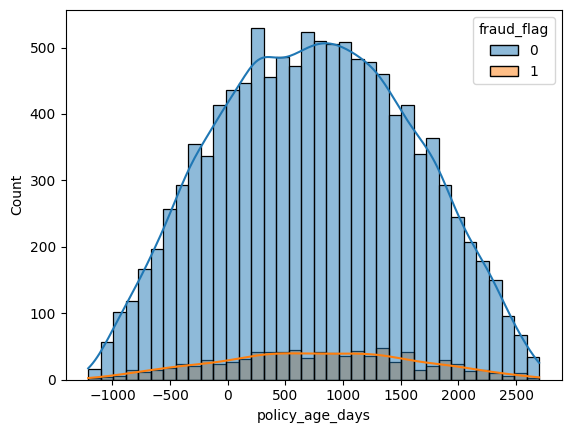

In [38]:
sns.histplot(df, x="policy_age_days", hue="fraud_flag", kde=True)

In [39]:
print(df['claim_datetime'].dtype, df['accident_datetime'].dtype)

datetime64[ns] object


In [40]:
df['claim_datetime'] = pd.to_datetime(df['claim_datetime'], errors='coerce', dayfirst=False)
df['accident_datetime'] = pd.to_datetime(df['accident_datetime'], errors='coerce', dayfirst=False)

In [41]:
#float días (incluye fracción)
df['submission_delay_days'] = (df['claim_datetime'] - df['accident_datetime']).dt.total_seconds() / 86400

# o entero (días completos)
# df['submission_delay_days'] = (df['claim_datetime'] - df['accident_datetime']).dt.days

<Axes: xlabel='submission_delay_days', ylabel='Count'>

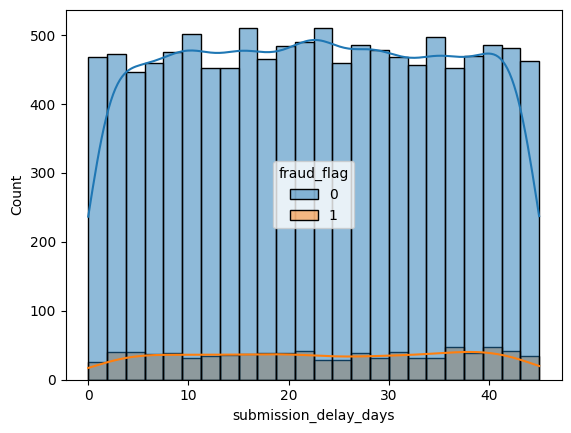

In [42]:
sns.histplot(df, x="submission_delay_days", hue="fraud_flag", kde=True)

In [43]:
# extraer ciudad del repair_workshop (ej: "Garage Ramírez - Murcia")
df['repair_workshop_city'] = df['repair_workshop'].str.split('-').str[-1].str.strip().str.lower()

# construir mapa city: province desde el propio df_customers
city2prov = df[['city','province']].drop_duplicates().dropna(subset=['city']).set_index('city')['province'].str.lower().to_dict()

df['accident_province_from_workshop'] = df['repair_workshop_city'].map(city2prov)

df['accident_in_same_province_as_customer'] = (
    df['accident_province_from_workshop'].fillna('').str.lower() ==
    df['province'].fillna('').str.lower()
)

In [44]:
df.groupby(["accident_in_same_province_as_customer", "fraud_flag"]).size().unstack(1)

fraud_flag,0,1
accident_in_same_province_as_customer,,
False,11389,878


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'murcia'),
  Text(1, 0, 'coruña'),
  Text(2, 0, 'vigo'),
  Text(3, 0, 'valencia'),
  Text(4, 0, 'barcelona'),
  Text(5, 0, 'vitoria'),
  Text(6, 0, 'valladolid'),
  Text(7, 0, 'sevilla'),
  Text(8, 0, 'las palmas'),
  Text(9, 0, 'hospitalet'),
  Text(10, 0, 'zaragoza'),
  Text(11, 0, 'gijón'),
  Text(12, 0, 'bilbao'),
  Text(13, 0, 'elche'),
  Text(14, 0, 'alicante'),
  Text(15, 0, 'málaga'),
  Text(16, 0, 'madrid'),
  Text(17, 0, 'palma'),
  Text(18, 0, 'granada'),
  Text(19, 0, 'córdoba')])

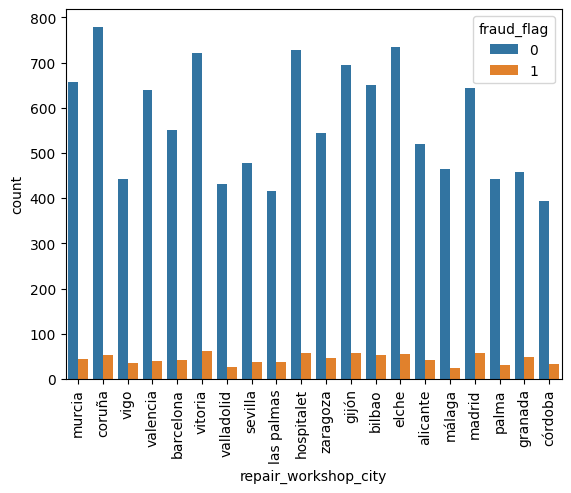

In [45]:
from matplotlib import pyplot as plt
# Invierto los ejes para ver mejor las ciudades
sns.countplot(data=df, x='repair_workshop_city', hue='fraud_flag')
plt.xticks(rotation=90)

In [46]:
# Ver los cambios de dirección: un cambio reciente puede indicar fraude
df['address_change'] = df['last_address_change_date'].notna().astype(int)
df.groupby(["address_change", "fraud_flag"]).size().unstack(1)

fraud_flag,0,1
address_change,,
0,5210,372
1,6179,506


In [47]:
# Hyperparameter Tuning with GridSearchCV (sin data leakage)
from sklearn.model_selection import FixedThresholdClassifier


# Split antes de tuning para no usar todo el dataset en GridSearch
X = df.drop(columns='fraud_flag')
y = df['fraud_flag']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
feature_columns = X_train.columns.tolist()

# Modelo base
lr_clf = get_base_pipeline(feature_columns)
lr_clf.set_params(
    classifier=FixedThresholdClassifier(
        estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
        threshold=0.5,
    )
)

# Separamos grids para evitar combinaciones inválidas solver/penalty
param_grid = [
    {
        'classifier__estimator__penalty': [None],
        'classifier__estimator__solver': ['lbfgs', 'newton-cg', 'saga'],
        'classifier__threshold': [0.3, 0.35, 0.4],
    },
    {
        'classifier__estimator__penalty': ['l2'],
        'classifier__estimator__solver': ['lbfgs', 'newton-cg', 'liblinear'],
        'classifier__estimator__C': [ 0.001, 0.01, 0.1, 1],
        'classifier__threshold': [0.3, 0.35, 0.4],
    },
    {
        'classifier__estimator__penalty': ['l1'],
        'classifier__estimator__solver': ['liblinear', 'saga'],
        'classifier__estimator__C': [ 0.001, 0.01, 0.1, 1],
        'classifier__threshold': [0.3, 0.35, 0.4],
    },
]

# CV temporal para clasificacion desbalanceada
cv = TimeSeriesSplit(n_splits=5)

time_order = X_train['claim_datetime'].sort_values().index
X_train_sorted = X_train.loc[time_order].reset_index(drop=True)
y_train_sorted = y_train.loc[time_order].reset_index(drop=True)

# IMPORTANTE: usar fbeta_scorer con β=2.77 (no β=2)
grid_search = GridSearchCV(lr_clf, param_grid, n_jobs=-1, cv=cv, scoring=fbeta_scorer)
grid_search.fit(X_train_sorted, y_train_sorted)


C:\Users\Miguel Fernández\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['accident_province_from_workshop']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('preprocess',
                                        Pipeline(steps=[('trf',
                                                         ColumnTransformer(transformers=[('trf',
                                                                                          FunctionTransformer(feature_names_out=<function base_transform_names_out at 0x000001AA91E8E480>,
                                                                                                              func=<function base_transform at 0x000001AA91E8C680>),
                                                                                          ['fault',
                                                                                           'accident_...
                          'classifier__estimator__solver': ['lbfgs',
                                                            'newton-cg',
                                                            'liblinear'],
                          'classifier__threshold': [0.4, 0.7, 0.9]},
                         {'classifier__estimator__C': [0.001, 0.01, 0.1, 1],
                          'classifier__estimator__penalty': ['l1'],
                          'classifier__estimator__solver': ['liblinear',
                                                            'saga'],
                          'classifier__threshold': [0.4, 0.7, 0.9]}],
             scoring=make_scorer(fbeta_score, response_method='predict', beta=2))

In [48]:
# CV score sobre train
default_cv_score = cross_validate(
    lr_clf,
    X_train_sorted,
    y_train_sorted,
    cv=cv,
    scoring=fbeta_276_scorer
)
print('Default F beta CV (train):', np.mean(default_cv_score['test_score']))

if not hasattr(grid_search, 'best_params_'):
    grid_search.fit(X_train_sorted, y_train_sorted)

print('Best Parameters:', grid_search.best_params_)
print('Best F beta CV:', grid_search.best_score_)

# Evaluate on Validation Set
y_pred = grid_search.predict(X_val)
print('Accuracy on Validation Set:', accuracy_score(y_val, y_pred))
print('Recall (1) on Validation Set:', recall_score(y_val, y_pred, pos_label=1))
print('Precision (1) on Validation Set:', precision_score(y_val, y_pred, pos_label=1))
print('F1 (1) on Validation Set:', f1_score(y_val, y_pred, pos_label=1))
print('Classification Report:')
print(classification_report(y_val, y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_val, y_pred))

C:\Users\Miguel Fernández\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['accident_province_from_workshop']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
C:\Users\Miguel Fernández\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['accident_province_from_workshop']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
C:\Users\Miguel Fernández\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['accident_province_from_workshop']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
C:\Users\Miguel Fernández\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_ba

Default F beta CV (train): 0.2092941238873709
Best Parameters: {'classifier__estimator__C': 0.001, 'classifier__estimator__penalty': 'l2', 'classifier__estimator__solver': 'lbfgs', 'classifier__threshold': 0.4}
Best F beta CV: 0.2790892575160651
Accuracy on Validation Set: 0.07212713936430318
Recall (1) on Validation Set: 1.0
Precision (1) on Validation Set: 0.07174887892376682
F1 (1) on Validation Set: 0.13389121338912133
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.00      0.00      2278
           1       0.07      1.00      0.13       176

    accuracy                           0.07      2454
   macro avg       0.54      0.50      0.07      2454
weighted avg       0.93      0.07      0.01      2454

Confusion Matrix:
[[   1 2277]
 [   0  176]]


C:\Users\Miguel Fernández\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['accident_province_from_workshop']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
C:\Users\Miguel Fernández\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['accident_province_from_workshop']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


## POSTPROCESS — Análisis económico del modelo de detección de fraude

In [49]:
# ============================================================
# ANÁLISIS ECONÓMICO — Matriz de costes del enunciado
# ============================================================

# Re-entrenar el mejor pipeline sobre todo el train
best_pipe = grid_search.best_estimator_
best_pipe.fit(X_train, y_train)

# Predecir probabilidades sobre validación
X_val_transformed = best_pipe.named_steps['preprocess'].transform(X_val)
y_proba = best_pipe.named_steps['classifier'].estimator_.predict_proba(X_val_transformed)[:, 1]

# ── Escenario sin modelo ──
fraudes_val = y_val.sum()
coste_sin_modelo = fraudes_val * C_FRAUDE
print(f"Fraudes en validación: {fraudes_val}")
print(f"Coste sin modelo (se pagan todos): {coste_sin_modelo:,.0f} €")
print(f"{'='*60}")


In [50]:
# ============================================================
# OPTIMIZACIÓN DE UMBRAL θ
# ============================================================

# Buscar el umbral que maximiza el ahorro neto
mejor_theta, df_thresholds = optimizar_umbral(y_val, y_proba)


C:\Users\Miguel Fernández\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['accident_province_from_workshop']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
C:\Users\Miguel Fernández\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['accident_province_from_workshop']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


In [51]:
# ============================================================
# VISUALIZACIÓN: Ahorro neto vs Umbral
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Ahorro neto por umbral
axes[0].plot(df_thresholds['threshold'], df_thresholds['ahorro'], 'b-', linewidth=2)
axes[0].axvline(x=mejor_theta, color='r', linestyle='--', label=f'Umbral óptimo: {mejor_theta:.2f}')
axes[0].set_xlabel('Umbral θ', fontsize=12)
axes[0].set_ylabel('Ahorro neto (€)', fontsize=12)
axes[0].set_title('Ahorro neto vs Umbral de decisión', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Precision y Recall por umbral
axes[1].plot(df_thresholds['threshold'], df_thresholds['precision'], 'g-', linewidth=2, label='Precision')
axes[1].plot(df_thresholds['threshold'], df_thresholds['recall'], 'b-', linewidth=2, label='Recall')
axes[1].axvline(x=mejor_theta, color='r', linestyle='--', label=f'Umbral óptimo: {mejor_theta:.2f}')
axes[1].set_xlabel('Umbral θ', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Precision vs Recall por Umbral', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Total retorno por siniestro sin modelo: -1821.96 €
Total retorno sin modelo: -4471.08 K€
---------------------------------------------------------------
Máximo retorno por siniestro (detección perfecta): -1648.61 €
Máximo retorno (detección perfecta): -4045.69 K€
---------------------------------------------------------------
Ahorro potencial detectando todo el fraude: 425.39 K€


In [52]:
# ============================================================
# RESULTADO FINAL CON UMBRAL ÓPTIMO
# ============================================================

# Aplicar umbral óptimo
y_pred_optimo = (y_proba >= mejor_theta).astype(int)

print("RESULTADO CON UMBRAL ÓPTIMO")
print("=" * 60)
ahorro_final = print_ahorro_neto(y_val, y_pred_optimo)

print(f"\n{'='*60}")
print("PROYECCIÓN ANUAL (15.000 siniestros)")
print("=" * 60)
factor = 15000 / len(y_val)
print(f"Ahorro neto proyectado: {ahorro_final * factor:>12,.0f} €")
print(f"Coste sin modelo:       {y_val.sum() * C_FRAUDE * factor:>12,.0f} €")

# F-beta score con el umbral óptimo
from sklearn.metrics import fbeta_score, classification_report
print(f"\nF-beta (β={BETA:.2f}): {fbeta_score(y_val, y_pred_optimo, beta=BETA):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val, y_pred_optimo, target_names=['Legítimo', 'Fraude']))


Umbral de score: 0.1
  Siniestros rechazados: 2454 (100.0%)
  TP=176, FP=2278, FN=0, TN=0
  Total retorno por siniestro: 760.9 €
  Total retorno: 1867.26 K€
------------------------------------------------------------------------------------------
Umbral de score: 0.2
  Siniestros rechazados: 2454 (100.0%)
  TP=176, FP=2278, FN=0, TN=0
  Total retorno por siniestro: 760.9 €
  Total retorno: 1867.26 K€
------------------------------------------------------------------------------------------
Umbral de score: 0.3
  Siniestros rechazados: 2454 (100.0%)
  TP=176, FP=2278, FN=0, TN=0
  Total retorno por siniestro: 760.9 €
  Total retorno: 1867.26 K€
------------------------------------------------------------------------------------------
Umbral de score: 0.4
  Siniestros rechazados: 2453 (100.0%)
  TP=176, FP=2277, FN=0, TN=1
  Total retorno por siniestro: 760.9 €
  Total retorno: 1867.26 K€
------------------------------------------------------------------------------------------
Umbral d

C:\Users\Miguel Fernández\AppData\Local\Temp\ipykernel_24080\495059070.py:23: RuntimeWarning: invalid value encountered in divide
  return (final_positive_returns + final_negative_returns) / (len_positive + len_negative)


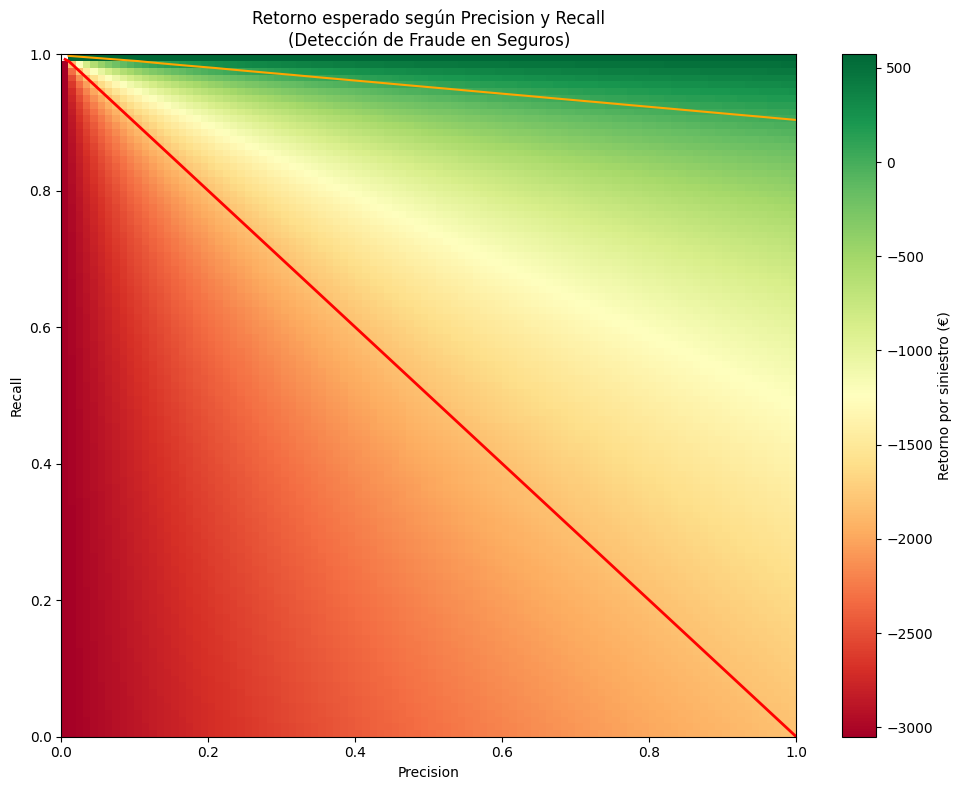

In [54]:
import matplotlib.pyplot as plt

precision_range = np.linspace(0, 1, 100)
recall_range = np.linspace(0, 1, 100)
precision_grid, recall_grid = np.meshgrid(precision_range, recall_range)


def get_claim_return(x, target, precision, recall):
    """
    Estima retorno por siniestro dado precision y recall del modelo.
    - Precision alta -> pocos legítimos rechazados
    - Recall alto -> más fraudes detectados
    """
    total_positive_returns = x[x > 0]
    total_negative_returns = x[x < 0]

    final_positive_returns = total_positive_returns.sum() * precision
    final_negative_returns = total_negative_returns.sum() * (1 - recall)

    len_positive = len(total_positive_returns) * precision
    len_negative = len(total_negative_returns) * (1 - recall)

    return (final_positive_returns + final_negative_returns) / (len_positive + len_negative)


# Calcular retorno para cada par precision/recall
claim_returns = get_claim_return(
    X_holdout['return'], X_holdout['target'],
    precision_grid, recall_grid
)

# Plot heatmap
plt.figure(figsize=(10, 8))
plt.imshow(claim_returns, extent=[0, 1, 0, 1], origin='lower', cmap='RdYlGn', aspect='auto')
plt.colorbar(label='Retorno por siniestro (€)')
plt.xlabel('Precision')
plt.ylabel('Recall')
plt.title('Retorno esperado según Precision y Recall\n(Detección de Fraude en Seguros)')

# Líneas de referencia
avg_return_no_model = X_holdout['return'].mean()
# Ordenar niveles de contorno en orden ascendente
levels = sorted([0., avg_return_no_model])
plt.contour(precision_grid, recall_grid, claim_returns,
            levels=levels, colors=['red', 'orange'], linewidths=[2, 1.5])

plt.tight_layout()
plt.show()